In [1]:
from NN_model_helper import (evaluate_fold_TL, set_freeze_mode, plot_training_progress, find_optimal_clusters)
from pathlib import Path
import sys
import pandas as pd
from sklearn.model_selection import StratifiedKFold
import numpy as np
from NN_model import ImprovedNN 

/opt/anaconda3/envs/Surabie_S_clean_v2/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [16]:
from imblearn.over_sampling import KMeansSMOTE
from sklearn.cluster import KMeans
from sklearn.neighbors import NearestNeighbors


In [17]:
def kmeans_smote_for_regression(X_tr, y_tr, cluster_tr, *,
                               sampling_strategy="not majority",
                               random_state=0,
                               k_neighbors=3,
                               mp_knn=5):
    """
    Oversample X within training set using KMeansSMOTE on cluster labels,
    then assign MP to synthetic points using kNN average of real samples
    from the same cluster.

    Returns: X_aug, y_aug, cluster_aug
    """
    X_tr = np.asarray(X_tr, dtype=np.float32)
    y_tr = np.asarray(y_tr, dtype=np.float32)
    cluster_tr = np.asarray(cluster_tr)

    # ---- Build a safe sampling_strategy dict (skip tiny clusters) ----
    vc = pd.Series(cluster_tr).value_counts()

    # SMOTE needs at least k_neighbors + 1 points in a class to even work
    min_required = max(k_neighbors + 1, 6)   # 6 is a practical floor
    eligible = vc[vc >= min_required].index.tolist()

    # If caller passed a string strategy, convert it into a dict strategy
    if isinstance(sampling_strategy, str):
        # Raise eligible clusters up to the median size (conservative)
        target = int(vc[eligible].median()) if len(eligible) else int(vc.median())
        sampling_strategy = {
            int(cl): target
            for cl in eligible
            if vc[cl] < target
        }

    # If nothing is eligible to oversample, return unchanged
    if not sampling_strategy:
        return X_tr, y_tr, cluster_tr

    # ---- KMeansSMOTE with small internal kmeans ----
    kms = KMeansSMOTE(
        sampling_strategy=sampling_strategy,
        random_state=random_state,
        k_neighbors=min(k_neighbors, min_required - 1),
        cluster_balance_threshold=0.01,                 # more permissive
        kmeans_estimator=KMeans(n_clusters=2, random_state=random_state)  # key fix
    )

    X_res, cluster_res = kms.fit_resample(X_tr, cluster_tr)

    n_orig = X_tr.shape[0]
    n_new  = X_res.shape[0] - n_orig

    # If nothing got generated, just return original
    if n_new <= 0:
        return X_tr, y_tr, cluster_tr

    X_syn = X_res[n_orig:]
    cluster_syn = cluster_res[n_orig:]

    # --- Assign MP to synthetic points ---
    y_syn = np.empty((n_new,), dtype=np.float32)

    # Build per-cluster neighbor structures on REAL points only
    for cl in np.unique(cluster_syn):
        real_idx = np.where(cluster_tr == cl)[0]
        syn_idx  = np.where(cluster_syn == cl)[0]

        # If a cluster has too few real points, fallback to global neighbors
        if len(real_idx) < 2:
            nn = NearestNeighbors(n_neighbors=min(mp_knn, len(X_tr))).fit(X_tr)
            dists, inds = nn.kneighbors(X_syn[syn_idx])
            y_syn[syn_idx] = y_tr[inds].mean(axis=1).astype(np.float32)
            continue

        nn = NearestNeighbors(n_neighbors=min(mp_knn, len(real_idx))).fit(X_tr[real_idx])
        dists, inds = nn.kneighbors(X_syn[syn_idx])
        y_syn[syn_idx] = y_tr[real_idx][inds].mean(axis=1).astype(np.float32)

    # Combine
    X_aug = np.vstack([X_tr, X_syn]).astype(np.float32)
    y_aug = np.concatenate([y_tr, y_syn]).astype(np.float32)
    cluster_aug = np.concatenate([cluster_tr, cluster_syn])

    return X_aug, y_aug, cluster_aug

In [7]:
df = pd.read_parquet("../Ro5/artifacts/final_dataset_RDKit_scaled.parquet")
df.head()

,SMILES,MP,Type,Ro5,RDKit_SlogP_VSA8,RDKit_PEOE_VSA7,RDKit_NumHeteroatoms,RDKit_Phi,RDKit_VSA_EState6,RDKit_MaxPartialCharge,...,RDKit_fr_COO,RDKit_fr_quatN,RDKit_BCUT2D_MWLOW,RDKit_SlogP_VSA2,RDKit_fr_Ar_OH,RDKit_fr_allylic_oxid,RDKit_fr_isocyan,RDKit_NHOHCount,RDKit_fr_ArN,RDKit_Chi2v
0,ON=Cc1cscc1,122.0,Train,1,-0.467993,-0.451517,-0.510997,-0.712620,-0.742496,-1.342155,...,-0.358177,-0.031699,0.241521,-0.411449,-0.305637,-0.203385,-0.052129,-0.072787,-0.268728,-0.947083
1,O=C1CC[C@]2(C(=C1)CC[C@@H]1[C@@H]2[C@H](O)C[C@...,205.5,Train,1,-0.467993,2.138147,-0.147901,-0.265642,-0.996300,-0.594938,...,-0.358177,-0.031699,-0.606166,0.935386,-0.305637,0.957963,-0.052129,-0.072787,-0.268728,1.927702
2,[O-][n+]1ccccc1,64.0,Train,1,-0.467993,-1.298520,-0.874093,-0.941809,-0.297425,-0.466599,...,-0.358177,-0.031699,0.361264,-1.078546,-0.305637,-0.203385,-0.052129,-0.839721,-0.268728,-1.265804
3,OC1CCC2(C(C1)CC=C1C2CCC2(C1CCC2C(CCC(C(C)C)C)C...,146.0,Train,1,-0.467993,3.917541,-1.237189,0.730222,-0.996300,-1.506755,...,-0.358177,-0.031699,-0.587023,-0.423794,-0.305637,2.119311,-0.052129,-0.072787,-0.268728,3.046397
4,CC(=O)c1ccc(cc1)Br,51.0,Train,1,-0.467993,-0.339266,-0.874093,-0.521941,-0.008852,-0.636808,...,-0.358177,-0.031699,0.033078,-0.740774,-0.305637,-0.203385,-0.052129,-0.839721,-0.268728,-0.608934


In [8]:
df_bro5 = df[
    (df["Type"] == "Train") &
    (df["Ro5"] == 0)
].copy()

print("Shape:", df_bro5.shape)
print(df_bro5[["Type", "Ro5"]].value_counts())

Shape: (257, 91)
Type   Ro5
Train  0      257
Name: count, dtype: int64


In [9]:
df_bro5.head()

,SMILES,MP,Type,Ro5,RDKit_SlogP_VSA8,RDKit_PEOE_VSA7,RDKit_NumHeteroatoms,RDKit_Phi,RDKit_VSA_EState6,RDKit_MaxPartialCharge,...,RDKit_fr_COO,RDKit_fr_quatN,RDKit_BCUT2D_MWLOW,RDKit_SlogP_VSA2,RDKit_fr_Ar_OH,RDKit_fr_allylic_oxid,RDKit_fr_isocyan,RDKit_NHOHCount,RDKit_fr_ArN,RDKit_Chi2v
63,N#C/C(=C\c1ccc(cc1)F)/c1nc(c(s1)/N=N/c1c(Br)cc...,171.0,Train,0,1.254957,2.461111,1.667578,1.005520,0.598887,-0.617571,...,-0.358177,-0.031699,0.013009,-0.787455,-0.305637,0.957963,-0.052129,-0.839721,-0.268728,1.716602
75,OC[C@H]1O[C@]([C@H]([C@@H]1O[C@@H]1O[C@H](CO)[...,175.5,Train,0,-0.467993,-1.298520,2.393770,0.690566,-0.996300,-0.145301,...,-0.358177,-0.031699,-0.119569,5.665969,-0.305637,-0.203385,-0.052129,5.295755,-0.268728,0.372907
88,BrC(CC1(C(=O)C2(C(C1CC2)(C)C)C)C1(CC(Cc2ccccc2...,215.0,Train,0,-0.467993,2.988180,-0.147901,1.180778,1.874850,-0.744693,...,-0.358177,-0.031699,-0.611127,0.160864,-0.305637,-0.203385,-0.052129,-0.839721,-0.268728,5.225337
111,Clc1nc(Oc2cc(cc(c2)Oc2nc(Cl)nc(n2)Cl)Oc2nc(Cl)...,240.0,Train,0,-0.467993,2.205250,4.935440,1.115963,-0.507562,0.753828,...,-0.358177,-0.031699,0.144159,1.541271,-0.305637,-0.203385,-0.052129,-0.839721,-0.268728,1.073042
267,CC(=O)OCC12OC1C(C1C2C(OC=C1)OC1OC(COC(=O)C)C(C...,135.0,Train,0,-0.467993,0.228793,4.935440,2.519538,-0.226500,0.843929,...,-0.358177,-0.031699,-0.241457,5.334580,-0.305637,-0.203385,-0.052129,-0.839721,-0.268728,2.941378


X_scaled shape: (257, 87)
Num features: 87


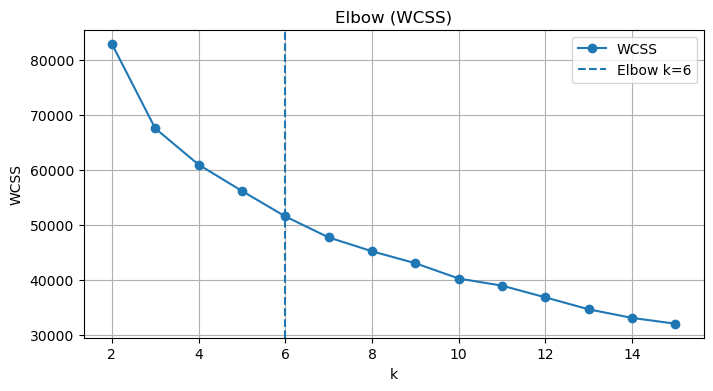

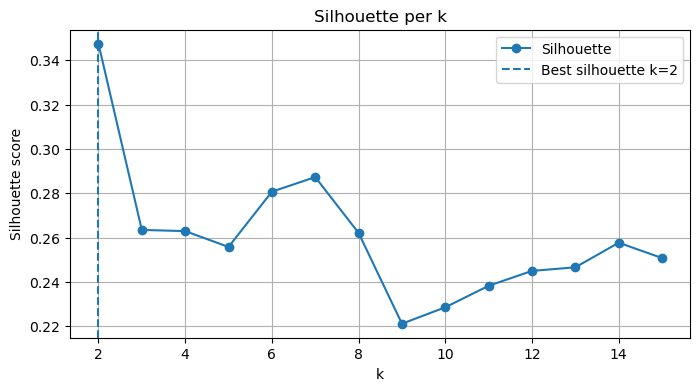

Elbow k: 6 | Best silhouette k: 2 | Selected k_opt: 6


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from kneed import KneeLocator

BASE = Path.cwd()
artifacts_dir = BASE / "artifacts"
artifacts_dir.mkdir(parents=True, exist_ok=True)


# 2) Define feature columns (already scaled), Exclude metadata/labels/non-features

exclude = {"SMILES", "MP", "Type", "Ro5"}
num_cols = df_bro5.select_dtypes(include=[np.number]).columns
feature_cols = [c for c in num_cols if c not in exclude]

X_scaled = df_bro5[feature_cols].to_numpy(dtype=np.float32)

print("X_scaled shape:", X_scaled.shape)
print("Num features:", len(feature_cols))


# 3) Find optimal k

random_state = 0
k_opt = find_optimal_clusters(X_scaled=X_scaled, max_k=15, random_state=random_state, plot=True)

if k_opt is None:
    k_opt = 3
    print("No clear elbow/silhouette; defaulting to k=3.")


# 4) Fit final kmeans + assign clusters

final_kmeans = KMeans(
    n_clusters=int(k_opt),
    init="k-means++",
    n_init=10,
    random_state=random_state
)

cluster_labels = final_kmeans.fit_predict(X_scaled)

assert len(cluster_labels) == len(df_bro5), "Cluster labels length != df rows (mismatch)."

df_clustered = df_bro5.copy()
df_clustered["Structure_Cluster"] = cluster_labels


In [11]:
df_clustered.head()

,SMILES,MP,Type,Ro5,RDKit_SlogP_VSA8,RDKit_PEOE_VSA7,RDKit_NumHeteroatoms,RDKit_Phi,RDKit_VSA_EState6,RDKit_MaxPartialCharge,...,RDKit_fr_quatN,RDKit_BCUT2D_MWLOW,RDKit_SlogP_VSA2,RDKit_fr_Ar_OH,RDKit_fr_allylic_oxid,RDKit_fr_isocyan,RDKit_NHOHCount,RDKit_fr_ArN,RDKit_Chi2v,Structure_Cluster
63,N#C/C(=C\c1ccc(cc1)F)/c1nc(c(s1)/N=N/c1c(Br)cc...,171.0,Train,0,1.254957,2.461111,1.667578,1.005520,0.598887,-0.617571,...,-0.031699,0.013009,-0.787455,-0.305637,0.957963,-0.052129,-0.839721,-0.268728,1.716602,5
75,OC[C@H]1O[C@]([C@H]([C@@H]1O[C@@H]1O[C@H](CO)[...,175.5,Train,0,-0.467993,-1.298520,2.393770,0.690566,-0.996300,-0.145301,...,-0.031699,-0.119569,5.665969,-0.305637,-0.203385,-0.052129,5.295755,-0.268728,0.372907,3
88,BrC(CC1(C(=O)C2(C(C1CC2)(C)C)C)C1(CC(Cc2ccccc2...,215.0,Train,0,-0.467993,2.988180,-0.147901,1.180778,1.874850,-0.744693,...,-0.031699,-0.611127,0.160864,-0.305637,-0.203385,-0.052129,-0.839721,-0.268728,5.225337,5
111,Clc1nc(Oc2cc(cc(c2)Oc2nc(Cl)nc(n2)Cl)Oc2nc(Cl)...,240.0,Train,0,-0.467993,2.205250,4.935440,1.115963,-0.507562,0.753828,...,-0.031699,0.144159,1.541271,-0.305637,-0.203385,-0.052129,-0.839721,-0.268728,1.073042,5
267,CC(=O)OCC12OC1C(C1C2C(OC=C1)OC1OC(COC(=O)C)C(C...,135.0,Train,0,-0.467993,0.228793,4.935440,2.519538,-0.226500,0.843929,...,-0.031699,-0.241457,5.334580,-0.305637,-0.203385,-0.052129,-0.839721,-0.268728,2.941378,0


In [12]:
TARGET_COL = "MP"

exclude = {"SMILES", TARGET_COL, "Type", "Ro5", "Structure_Cluster"}
num_cols = df_clustered.select_dtypes(include=[np.number]).columns
feature_cols = [c for c in num_cols if c not in exclude]

X = df_clustered[feature_cols].to_numpy(np.float32) 
y = df_clustered[TARGET_COL].to_numpy(np.float32)
y_strat = df_clustered["Structure_Cluster"].astype(str).to_numpy()

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=10)
folds = [(tr, va) for tr, va in skf.split(X, y_strat)]

print("Total samples:", len(X))
print("Num features:", X.shape[1])
print("Num folds:", len(folds))
print()

for i, (tr_idx, va_idx) in enumerate(folds):
    print(
        f"Fold {i:2d} | "
        f"Train: {len(tr_idx):4d} | "
        f"Val: {len(va_idx):4d}"
    )


Total samples: 257
Num features: 87
Num folds: 10

Fold  0 | Train:  231 | Val:   26
Fold  1 | Train:  231 | Val:   26
Fold  2 | Train:  231 | Val:   26
Fold  3 | Train:  231 | Val:   26
Fold  4 | Train:  231 | Val:   26
Fold  5 | Train:  231 | Val:   26
Fold  6 | Train:  231 | Val:   26
Fold  7 | Train:  232 | Val:   25
Fold  8 | Train:  232 | Val:   25
Fold  9 | Train:  232 | Val:   25


/opt/anaconda3/envs/Surabie_S_clean_v2/lib/python3.11/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 7 members, which is less than n_splits=10.
  warnings.warn(


In [18]:
from pathlib import Path
import json, joblib, numpy as np, pandas as pd, torch, optuna

BASELINE_CKPT = Path("/Users/sdl5_mp/Documents/GitHub/melting_point_2026/Ro5/artifacts/general_best_Ro5_RDKit/general_best_fold_6.pt")

# --- scenarios: name, vector (for your notes), freeze_level used by evaluate_fold_TL ---

HIDDEN_LAYERS = [256, 128, 64]   # must match baseline arch
N_TRIALS      = 20

OUT_ROOT = Path("artifacts/TL_Ro5_RDKit_KMeans_SMOTE")   # under the artifacts folder
OUT_ROOT.mkdir(parents=True, exist_ok=True)

def run_one_scenario(tag, freeze_vec, freeze_level):
    print(f"\n=== Scenario: {tag} | freeze={freeze_vec} (level={freeze_level}) ===")
    SCEN_OUT = OUT_ROOT / tag
    (SCEN_OUT / "trials").mkdir(parents=True, exist_ok=True)

    def objective_tl_fixed(trial):
        # fixed freeze level; tune the rest
        learning_rate = trial.suggest_float("learning_rate", 1e-5, 1e-3, log=True)
        weight_decay  = trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True)
        batch_size    = trial.suggest_categorical("batch_size", [16, 32, 64])
        dropout_rate  = trial.suggest_float("dropout_rate", 0.2, 0.5)

        trial_dir = SCEN_OUT / "trials" / f"trial_{trial.number:04d}"
        trial_dir.mkdir(parents=True, exist_ok=True)

        fold_metrics, rmses = [], []
        for fold_idx, (tr_idx, va_idx) in enumerate(folds):
            X_tr, y_tr = X[tr_idx], y[tr_idx]
            X_va, y_va = X[va_idx], y[va_idx]

            # clusters for KMeansSMOTE "classes"
            cluster_tr = y_strat[tr_idx]  # y_strat = Structure_Cluster as str
            # (optionally keep as int; str works too but int is nicer)
            cluster_tr = cluster_tr.astype(int)

            X_tr, y_tr, _ = kmeans_smote_for_regression(
                X_tr, y_tr, cluster_tr,
                sampling_strategy="not majority",  # or "auto" / dict per cluster
                random_state=0,
                k_neighbors=3,
                mp_knn=5
            )

            rmse, r2, q2, model, *_ = evaluate_fold_TL(
                trial=trial,
                fold_idx=fold_idx,
                X_train_scaled=X_tr, y_train=y_tr,
                X_val_scaled=X_va,   y_val=y_va,
                hidden_layers=HIDDEN_LAYERS, dropout_rate=dropout_rate,
                learning_rate=learning_rate, weight_decay=weight_decay,
                batch_size=batch_size, freeze_level=freeze_level,
                baseline_ckpt=BASELINE_CKPT,
                max_epochs=10**6, patience=30, min_delta=0.0,
                save_checkpoints=False
            )

            ckpt_path = trial_dir / f"fold_{fold_idx}_best.pth"
            torch.save(model.state_dict(), ckpt_path)

            fold_metrics.append({
                "fold": fold_idx,
                "rmse": float(rmse),
                "r2":   float(r2),
                "q2":   float(q2),
                "checkpoint": str(ckpt_path)
            })
            rmses.append(rmse)

        summary = {
            "scenario": tag,
            "freeze_vector": freeze_vec,
            "freeze_level": freeze_level,
            "trial_number": trial.number,
            "params": {
                "learning_rate": learning_rate,
                "weight_decay":  weight_decay,
                "batch_size":    batch_size,
                "dropout_rate":  dropout_rate,
                "hidden_layers": HIDDEN_LAYERS
            },
            "avg_rmse": float(np.mean(rmses)),
            "folds":    fold_metrics
        }
        with open(trial_dir / "summary.json", "w") as f:
            json.dump(summary, f, indent=2)

        return float(np.mean(rmses))

    # -- HPO
    study = optuna.create_study(direction="minimize")
    study.optimize(objective_tl_fixed, n_trials=N_TRIALS, gc_after_trial=True)

    # save study artifacts
    joblib.dump(study, SCEN_OUT / "study.joblib")
    study.trials_dataframe().to_csv(SCEN_OUT / "trials.csv", index=False)
    with open(SCEN_OUT / "best_params.json","w") as f:
        json.dump(study.best_params, f, indent=2)
    with open(SCEN_OUT / "best_value.txt","w") as f:
        f.write(f"{study.best_value:.6f}\n")
    print(f"[{tag}] Best avg RMSE: {study.best_value:.4f}")
    print(f"[{tag}] Best params:  {study.best_params}")

    # -- Final per-fold retrain with best params (to produce clean fold models + metrics)
    best = study.best_params
    FINAL_DIR = SCEN_OUT / "final_fold_models"
    FINAL_DIR.mkdir(parents=True, exist_ok=True)

    rows = []
    for fold_idx, (tr_idx, va_idx) in enumerate(folds):
        X_tr, y_tr = X[tr_idx], y[tr_idx]
        X_va, y_va = X[va_idx], y[va_idx]

        rmse, r2, q2, model, *_ = evaluate_fold_TL(
            trial=None,
            fold_idx=fold_idx,
            X_train_scaled=X_tr, y_train=y_tr,
            X_val_scaled=X_va,   y_val=y_va,
            hidden_layers=HIDDEN_LAYERS,
            dropout_rate=best["dropout_rate"],
            learning_rate=best["learning_rate"],
            weight_decay=best["weight_decay"],
            batch_size=best["batch_size"],
            freeze_level=freeze_level,
            baseline_ckpt=BASELINE_CKPT,
            max_epochs=10**6, patience=30, min_delta=0.0,
            save_checkpoints=False
        )

        ckpt = FINAL_DIR / f"fold_{fold_idx}_best.pth"
        torch.save(model.state_dict(), ckpt)
        rows.append({"fold": fold_idx, "rmse": float(rmse), "r2": float(r2), "q2": float(q2), "checkpoint": str(ckpt)})

    cv_df = pd.DataFrame(rows).sort_values("rmse").reset_index(drop=True)
    cv_df.to_csv(SCEN_OUT / "cv_final_metrics.csv", index=False)

    best_row = cv_df.iloc[0]
    manifest = {
        "scenario": tag,
        "freeze_vector": freeze_vec,
        "freeze_level": freeze_level,
        "best_fold": int(best_row["fold"]),
        "checkpoint": best_row["checkpoint"],
        "hidden_layers": HIDDEN_LAYERS,
        "best_params": best
    }
    with open(SCEN_OUT / "manifest.json","w") as f:
        json.dump(manifest, f, indent=2)

    print(f"[{tag}] Best fold: {manifest['best_fold']} → {manifest['checkpoint']}")
    return study, cv_df, manifest


# ---------- RUN ALL THREE ----------
SCENARIOS = [
    ("no_freeze",        [0,0,0], 0),
    ("freeze_fc1",       [1,0,0], 1),
    ("freeze_fc1_fc2",   [1,1,0], 2),
]

results = {}
for tag, vec, lvl in SCENARIOS:
    study, cv_df, manifest = run_one_scenario(tag, vec, lvl)
    results[tag] = {"best": study.best_value, "manifest": manifest}
print("\nSummary:", json.dumps(results, indent=2))

[I 2026-02-19 23:44:03,326] A new study created in memory with name: no-name-5de381bb-c994-4334-b201-6848a9034e57



=== Scenario: no_freeze | freeze=[0, 0, 0] (level=0) ===
Fold 0: TL on cpu | freeze=0 | lr=0.000519406
Freeze Level 0: all layers trainable
[Fold 0] Epoch    1 | Train 69.8503 | Val 44.3134 | ES 0/30


/Users/sdl5_mp/Documents/GitHub/melting_point_2026/bRo5_data_problem/NN_model_helper.py:428: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(baseline_ckpt, 

[Fold 0] Early stopping at epoch 47 (best Val Loss: 34.6426)
Fold 1: TL on cpu | freeze=0 | lr=0.000519406
Freeze Level 0: all layers trainable
[Fold 1] Epoch    1 | Train 70.4984 | Val 65.1611 | ES 0/30


/Users/sdl5_mp/Documents/GitHub/melting_point_2026/bRo5_data_problem/NN_model_helper.py:428: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(baseline_ckpt, 

...

[Fold 7] Epoch   50 | Train 55.1840 | Val 45.4866 | ES 1/30
[Fold 7] Epoch  100 | Train 51.4804 | Val 44.6103 | ES 25/30
[Fold 7] Early stopping at epoch 133 (best Val Loss: 43.7089)
Fold 8: TL on cpu | freeze=2 | lr=0.000467117
Freeze Level 2: freezing 2 block(s)
[Fold 8] Epoch    1 | Train 74.4910 | Val 46.8542 | ES 0/30


/Users/sdl5_mp/Documents/GitHub/melting_point_2026/bRo5_data_problem/NN_model_helper.py:428: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(baseline_ckpt, 

[Fold 8] Epoch   50 | Train 56.3727 | Val 33.8568 | ES 6/30
[Fold 8] Early stopping at epoch 74 (best Val Loss: 33.7309)
Fold 9: TL on cpu | freeze=2 | lr=0.000467117
Freeze Level 2: freezing 2 block(s)
[Fold 9] Epoch    1 | Train 66.2746 | Val 60.6849 | ES 0/30


/Users/sdl5_mp/Documents/GitHub/melting_point_2026/bRo5_data_problem/NN_model_helper.py:428: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(baseline_ckpt, 

[Fold 9] Early stopping at epoch 45 (best Val Loss: 58.3237)
[freeze_fc1_fc2] Best fold: 8 → artifacts/TL_Ro5_RDKit_KMeans_SMOTE/freeze_fc1_fc2/final_fold_models/fold_8_best.pth

Summary: {
  "no_freeze": {
    "best": 44.51779365539551,
    "manifest": {
      "scenario": "no_freeze",
      "freeze_vector": [
        0,
        0,
        0
      ],
      "freeze_level": 0,
      "best_fold": 8,
      "checkpoint": "artifacts/TL_Ro5_RDKit_KMeans_SMOTE/no_freeze/final_fold_models/fold_8_best.pth",
      "hidden_layers": [
        256,
        128,
        64
      ],
      "best_params": {
        "learning_rate": 0.00048733791518309767,
        "weight_decay": 0.0007133987119024935,
        "batch_size": 16,
        "dropout_rate": 0.2538567572092167
      }
    }
  },
  "freeze_fc1": {
    "best": 43.40832576751709,
    "manifest": {
      "scenario": "freeze_fc1",
      "freeze_vector": [
        1,
        0,
        0
      ],
      "freeze_level": 1,
      "best_fold": 8,
      "

In [19]:
from NN_model import ImprovedNN
import torch
import pandas as pd
from pathlib import Path
import json

def load_best_models_for_scenarios(
    root_dir="artifacts/TL_Ro5_RDKit_KMeans_SMOTE",
    scenarios=("no_freeze", "freeze_fc1", "freeze_fc1_fc2"),
):
    root_dir = Path(root_dir)
    models = {}
    manifests = {}

    for tag in scenarios:
        manifest_path = root_dir / tag / "manifest.json"
        cv_metrics_path = root_dir / tag / "cv_final_metrics.csv"

        # Load manifest
        with open(manifest_path, "r") as f:
            manifest = json.load(f)
        manifests[tag] = manifest

        # Load best RMSE from cv_final_metrics.csv
        cv_df = pd.read_csv(cv_metrics_path)
        best_row = cv_df.sort_values("rmse").iloc[0]
        best_rmse = float(best_row["rmse"])

        # Load checkpoint
        ckpt_path = Path(best_row["checkpoint"]).resolve()
        state = torch.load(ckpt_path, map_location="cpu")

        # Build model
        input_size = state["network.0.weight"].shape[1]
        hidden_layers = manifest["hidden_layers"]
        dropout_rate = manifest["best_params"]["dropout_rate"]

        model = ImprovedNN(
            input_size=input_size,
            hidden_layers=hidden_layers,
            dropout_rate=dropout_rate,
        )
        model.load_state_dict(state)
        model.eval()

        models[tag] = model

        print(f"Loaded model for scenario '{tag}'")
        print(f"  └─ Best fold checkpoint: {ckpt_path}")
        print(f"  └─ Best RMSE: {best_rmse:.4f}\n")

    return models, manifests

models, manifests = load_best_models_for_scenarios(
    root_dir="artifacts/TL_Ro5_RDKit_KMeans_SMOTE",
    scenarios=["no_freeze", "freeze_fc1", "freeze_fc1_fc2"]
)

Loaded model for scenario 'no_freeze'
  └─ Best fold checkpoint: /Users/sdl5_mp/Documents/GitHub/melting_point_2026/bRo5_data_problem/artifacts/TL_Ro5_RDKit_KMeans_SMOTE/no_freeze/final_fold_models/fold_8_best.pth
  └─ Best RMSE: 36.5396

Loaded model for scenario 'freeze_fc1'
  └─ Best fold checkpoint: /Users/sdl5_mp/Documents/GitHub/melting_point_2026/bRo5_data_problem/artifacts/TL_Ro5_RDKit_KMeans_SMOTE/freeze_fc1/final_fold_models/fold_8_best.pth
  └─ Best RMSE: 32.7440

Loaded model for scenario 'freeze_fc1_fc2'
  └─ Best fold checkpoint: /Users/sdl5_mp/Documents/GitHub/melting_point_2026/bRo5_data_problem/artifacts/TL_Ro5_RDKit_KMeans_SMOTE/freeze_fc1_fc2/final_fold_models/fold_8_best.pth
  └─ Best RMSE: 33.0123



/var/folders/4j/q1b8spls57ldz2j3g8k6nxh40000gn/T/ipykernel_26767/1381786165.py:31: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(ckpt_path, map_location="

In [21]:
import pandas as pd
from pathlib import Path

def print_rmse_all_folds(
    root_dir="artifacts/TL_Ro5_RDKit_KMeans_SMOTE",
    scenarios=("no_freeze", "freeze_fc1", "freeze_fc1_fc2"),
):
    root_dir = Path(root_dir)

    for tag in scenarios:
        cv_metrics_path = root_dir / tag / "cv_final_metrics.csv"

        if not cv_metrics_path.exists():
            print(f"[WARN] Missing CV metrics for scenario '{tag}'")
            continue

        cv_df = pd.read_csv(cv_metrics_path)

        print(f"\nScenario: {tag}")
        print("-" * (10 + len(tag)))

        # Expecting columns like: fold, rmse, r2, q2, checkpoint, ...
        for _, row in cv_df.iterrows():
            fold = row.get("fold", "N/A")
            rmse = row["rmse"]
            print(f"  Fold {fold}: RMSE = {rmse:.4f}")

        print(f"  Mean RMSE: {cv_df['rmse'].mean():.4f}")
        print(f"  Std  RMSE: {cv_df['rmse'].std():.4f}")

# Run it
print_rmse_all_folds(
    root_dir="artifacts/TL_Ro5_RDKit_KMeans_SMOTE",
    scenarios=["no_freeze", "freeze_fc1", "freeze_fc1_fc2"]
)


Scenario: no_freeze
-------------------
  Fold 8: RMSE = 36.5396
  Fold 0: RMSE = 38.0329
  Fold 1: RMSE = 39.0027
  Fold 2: RMSE = 39.6311
  Fold 7: RMSE = 43.0611
  Fold 4: RMSE = 44.7377
  Fold 5: RMSE = 52.9285
  Fold 3: RMSE = 53.8609
  Fold 6: RMSE = 56.4688
  Fold 9: RMSE = 56.6436
  Mean RMSE: 46.0907
  Std  RMSE: 8.0645

Scenario: freeze_fc1
--------------------
  Fold 8: RMSE = 32.7440
  Fold 0: RMSE = 34.8828
  Fold 1: RMSE = 35.4830
  Fold 7: RMSE = 36.3676
  Fold 2: RMSE = 36.9093
  Fold 4: RMSE = 47.4592
  Fold 9: RMSE = 53.2574
  Fold 3: RMSE = 54.6500
  Fold 5: RMSE = 54.7889
  Fold 6: RMSE = 56.6745
  Mean RMSE: 44.3217
  Std  RMSE: 9.8769

Scenario: freeze_fc1_fc2
------------------------
  Fold 8: RMSE = 33.0123
  Fold 0: RMSE = 36.5338
  Fold 2: RMSE = 37.0472
  Fold 1: RMSE = 46.2507
  Fold 7: RMSE = 46.9455
  Fold 4: RMSE = 50.1069
  Fold 3: RMSE = 52.9696
  Fold 5: RMSE = 54.3150
  Fold 9: RMSE = 58.0500
  Fold 6: RMSE = 58.1275
  Mean RMSE: 47.3358
  Std  RMSE:

TEST EVALUATION

In [22]:
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import joblib

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from NN_model import ImprovedNN  # adjust if needed

In [23]:
df = pd.read_parquet("../Ro5/artifacts/final_dataset_RDKit_scaled.parquet")
df.head()

,SMILES,MP,Type,Ro5,RDKit_SlogP_VSA8,RDKit_PEOE_VSA7,RDKit_NumHeteroatoms,RDKit_Phi,RDKit_VSA_EState6,RDKit_MaxPartialCharge,...,RDKit_fr_COO,RDKit_fr_quatN,RDKit_BCUT2D_MWLOW,RDKit_SlogP_VSA2,RDKit_fr_Ar_OH,RDKit_fr_allylic_oxid,RDKit_fr_isocyan,RDKit_NHOHCount,RDKit_fr_ArN,RDKit_Chi2v
0,ON=Cc1cscc1,122.0,Train,1,-0.467993,-0.451517,-0.510997,-0.712620,-0.742496,-1.342155,...,-0.358177,-0.031699,0.241521,-0.411449,-0.305637,-0.203385,-0.052129,-0.072787,-0.268728,-0.947083
1,O=C1CC[C@]2(C(=C1)CC[C@@H]1[C@@H]2[C@H](O)C[C@...,205.5,Train,1,-0.467993,2.138147,-0.147901,-0.265642,-0.996300,-0.594938,...,-0.358177,-0.031699,-0.606166,0.935386,-0.305637,0.957963,-0.052129,-0.072787,-0.268728,1.927702
2,[O-][n+]1ccccc1,64.0,Train,1,-0.467993,-1.298520,-0.874093,-0.941809,-0.297425,-0.466599,...,-0.358177,-0.031699,0.361264,-1.078546,-0.305637,-0.203385,-0.052129,-0.839721,-0.268728,-1.265804
3,OC1CCC2(C(C1)CC=C1C2CCC2(C1CCC2C(CCC(C(C)C)C)C...,146.0,Train,1,-0.467993,3.917541,-1.237189,0.730222,-0.996300,-1.506755,...,-0.358177,-0.031699,-0.587023,-0.423794,-0.305637,2.119311,-0.052129,-0.072787,-0.268728,3.046397
4,CC(=O)c1ccc(cc1)Br,51.0,Train,1,-0.467993,-0.339266,-0.874093,-0.521941,-0.008852,-0.636808,...,-0.358177,-0.031699,0.033078,-0.740774,-0.305637,-0.203385,-0.052129,-0.839721,-0.268728,-0.608934


In [24]:
df_test = df[
    (df["Type"] == "Test")
].copy()

print("Shape:", df_test.shape)

Shape: (5166, 91)


In [25]:
##################---------------------------- NO FREEZE TEST EVALUATION ----------------------------#######################

# PATHS

BASE = Path.cwd()  # wherever your notebook is running
CKPT_PTH = BASE / "artifacts/TL_Ro5_RDKit_KMeans_SMOTE/no_freeze/final_fold_models/fold_8_best.pth"

OUT_PRED_CSV = BASE / "artifacts/test_TL_Ro5_predictions_no_freeze_RDKit_KMeans_SMOTE.csv"

# MODEL PARAMETERS (must match checkpoint architecture)

HIDDEN_LAYERS = [256, 128, 64]
DROPOUT_RATE = 0.24086130274025735  # must match best params used for that checkpoint


NON_FEATURES = ["SMILES", "MP", "Type", "Ro5", "Structure_Cluster"]
feature_cols = [c for c in df_test.columns if c not in NON_FEATURES]
feature_cols = [c for c in feature_cols if pd.api.types.is_numeric_dtype(df_test[c])]


X_test = df_test[feature_cols].to_numpy(dtype=np.float32)
y_true = df_test["MP"].to_numpy(dtype=float)
smiles = df_test["SMILES"].astype(str).to_numpy()

print("Test rows:", len(df_test))
print("Features:", X_test.shape[1])


# Recreate model + load checkpoint

device = torch.device("cpu")

model = ImprovedNN(
    input_size=X_test.shape[1],
    hidden_layers=HIDDEN_LAYERS,
    dropout_rate=DROPOUT_RATE
).to(device)

loaded = torch.load(CKPT_PTH, map_location=device)

if isinstance(loaded, dict) and "model_state_dict" in loaded:
    model.load_state_dict(loaded["model_state_dict"], strict=True)
else:
    model.load_state_dict(loaded, strict=True)

model.eval()


# Predict

X_tensor = torch.tensor(X_test, dtype=torch.float32, device=device)

with torch.no_grad():
    y_pred = model(X_tensor).squeeze().cpu().numpy().astype(float)


# Evaluate

rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
mae  = float(mean_absolute_error(y_true, y_pred))
r2   = float(r2_score(y_true, y_pred))

print("\n=== TEST METRICS ===")
print(f"RMSE: {rmse:.4f}")
print(f"MAE : {mae:.4f}")
print(f"R^2 : {r2:.4f}")


# Save predictions

out_df = pd.DataFrame({
    "SMILES": smiles,
    "Type": df_test["Type"].astype(str).to_numpy(),
    "Ro5": df_test["Ro5"].to_numpy(),
    "exp MP": y_true,
    "pred MP": y_pred,
    "error": y_pred - y_true,
    "abs_error": np.abs(y_pred - y_true),
})

OUT_PRED_CSV.parent.mkdir(parents=True, exist_ok=True)
out_df.to_csv(OUT_PRED_CSV, index=False)
print(f"\nSaved predictions -> {OUT_PRED_CSV}")


rmse_total = np.sqrt(np.mean(out_df["error"] ** 2))
print(f"Total RMSE (all): {rmse_total:.3f}")

df_ro5 = out_df[out_df["Ro5"] == 1]
rmse_ro5 = np.sqrt(np.mean(df_ro5["error"] ** 2))
print(f"RMSE (Ro5): {rmse_ro5:.3f}")

df_bro5 = out_df[out_df["Ro5"] == 0]
rmse_bro5 = np.sqrt(np.mean(df_bro5["error"] ** 2))
print(f"RMSE (bRo5): {rmse_bro5:.3f}")

Test rows: 5166
Features: 87

=== TEST METRICS ===
RMSE: 48.2277
MAE : 38.3817
R^2 : 0.5410

Saved predictions -> /Users/sdl5_mp/Documents/GitHub/melting_point_2026/bRo5_data_problem/artifacts/test_TL_Ro5_predictions_no_freeze_RDKit_KMeans_SMOTE.csv
Total RMSE (all): 48.228
RMSE (Ro5): 48.100
RMSE (bRo5): 53.756


/var/folders/4j/q1b8spls57ldz2j3g8k6nxh40000gn/T/ipykernel_26767/997201577.py:39: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded = torch.load(CKPT_PTH, map_location=de

In [26]:
##################---------------------------- FC1 FREEZE TEST EVALUATION ----------------------------#######################

# PATHS

BASE = Path.cwd()  # wherever your notebook is running
CKPT_PTH = BASE / "artifacts/TL_Ro5_RDKit_KMeans_SMOTE/freeze_fc1/final_fold_models/fold_8_best.pth"

OUT_PRED_CSV = BASE / "artifacts/test_TL_Ro5_predictions_freeze_fc1_RDKit_KMeans_SMOTE.csv"

# MODEL PARAMETERS (must match checkpoint architecture)

HIDDEN_LAYERS = [256, 128, 64]
DROPOUT_RATE = 0.24086130274025735  # must match best params used for that checkpoint


NON_FEATURES = ["SMILES", "MP", "Type", "Ro5", "Structure_Cluster"]
feature_cols = [c for c in df_test.columns if c not in NON_FEATURES]
feature_cols = [c for c in feature_cols if pd.api.types.is_numeric_dtype(df_test[c])]


X_test = df_test[feature_cols].to_numpy(dtype=np.float32)
y_true = df_test["MP"].to_numpy(dtype=float)
smiles = df_test["SMILES"].astype(str).to_numpy()

print("Test rows:", len(df_test))
print("Features:", X_test.shape[1])


# Recreate model + load checkpoint

device = torch.device("cpu")

model = ImprovedNN(
    input_size=X_test.shape[1],
    hidden_layers=HIDDEN_LAYERS,
    dropout_rate=DROPOUT_RATE
).to(device)

loaded = torch.load(CKPT_PTH, map_location=device)

if isinstance(loaded, dict) and "model_state_dict" in loaded:
    model.load_state_dict(loaded["model_state_dict"], strict=True)
else:
    model.load_state_dict(loaded, strict=True)

model.eval()


# Predict

X_tensor = torch.tensor(X_test, dtype=torch.float32, device=device)

with torch.no_grad():
    y_pred = model(X_tensor).squeeze().cpu().numpy().astype(float)


# Evaluate

rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
mae  = float(mean_absolute_error(y_true, y_pred))
r2   = float(r2_score(y_true, y_pred))

print("\n=== TEST METRICS ===")
print(f"RMSE: {rmse:.4f}")
print(f"MAE : {mae:.4f}")
print(f"R^2 : {r2:.4f}")


# Save predictions

out_df = pd.DataFrame({
    "SMILES": smiles,
    "Type": df_test["Type"].astype(str).to_numpy(),
    "Ro5": df_test["Ro5"].to_numpy(),
    "exp MP": y_true,
    "pred MP": y_pred,
    "error": y_pred - y_true,
    "abs_error": np.abs(y_pred - y_true),
})

OUT_PRED_CSV.parent.mkdir(parents=True, exist_ok=True)
out_df.to_csv(OUT_PRED_CSV, index=False)
print(f"\nSaved predictions -> {OUT_PRED_CSV}")


rmse_total = np.sqrt(np.mean(out_df["error"] ** 2))
print(f"Total RMSE (all): {rmse_total:.3f}")

df_ro5 = out_df[out_df["Ro5"] == 1]
rmse_ro5 = np.sqrt(np.mean(df_ro5["error"] ** 2))
print(f"RMSE (Ro5): {rmse_ro5:.3f}")

df_bro5 = out_df[out_df["Ro5"] == 0]
rmse_bro5 = np.sqrt(np.mean(df_bro5["error"] ** 2))
print(f"RMSE (bRo5): {rmse_bro5:.3f}")

Test rows: 5166
Features: 87

=== TEST METRICS ===
RMSE: 46.8678
MAE : 37.8768
R^2 : 0.5665

Saved predictions -> /Users/sdl5_mp/Documents/GitHub/melting_point_2026/bRo5_data_problem/artifacts/test_TL_Ro5_predictions_freeze_fc1_RDKit_KMeans_SMOTE.csv
Total RMSE (all): 46.868
RMSE (Ro5): 46.750
RMSE (bRo5): 51.999


/var/folders/4j/q1b8spls57ldz2j3g8k6nxh40000gn/T/ipykernel_26767/2634011812.py:39: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded = torch.load(CKPT_PTH, map_location=d

In [27]:
##################---------------------------- FC1, FC2 FREEZE TEST EVALUATION ----------------------------#######################

# PATHS

BASE = Path.cwd()  # wherever your notebook is running
CKPT_PTH = BASE / "artifacts/TL_Ro5_RDKit_KMeans_SMOTE/freeze_fc1_fc2/final_fold_models/fold_8_best.pth"

OUT_PRED_CSV = BASE / "artifacts/test_TL_Ro5_predictions_freeze_fc1_fc2_RDKit_KMeans_SMOTE.csv"

# MODEL PARAMETERS (must match checkpoint architecture)

HIDDEN_LAYERS = [256, 128, 64]
DROPOUT_RATE = 0.24086130274025735  # must match best params used for that checkpoint


NON_FEATURES = ["SMILES", "MP", "Type", "Ro5", "Structure_Cluster"]
feature_cols = [c for c in df_test.columns if c not in NON_FEATURES]
feature_cols = [c for c in feature_cols if pd.api.types.is_numeric_dtype(df_test[c])]


X_test = df_test[feature_cols].to_numpy(dtype=np.float32)
y_true = df_test["MP"].to_numpy(dtype=float)
smiles = df_test["SMILES"].astype(str).to_numpy()

print("Test rows:", len(df_test))
print("Features:", X_test.shape[1])


# Recreate model + load checkpoint

device = torch.device("cpu")

model = ImprovedNN(
    input_size=X_test.shape[1],
    hidden_layers=HIDDEN_LAYERS,
    dropout_rate=DROPOUT_RATE
).to(device)

loaded = torch.load(CKPT_PTH, map_location=device)

if isinstance(loaded, dict) and "model_state_dict" in loaded:
    model.load_state_dict(loaded["model_state_dict"], strict=True)
else:
    model.load_state_dict(loaded, strict=True)

model.eval()


# Predict

X_tensor = torch.tensor(X_test, dtype=torch.float32, device=device)

with torch.no_grad():
    y_pred = model(X_tensor).squeeze().cpu().numpy().astype(float)


# Evaluate

rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
mae  = float(mean_absolute_error(y_true, y_pred))
r2   = float(r2_score(y_true, y_pred))

print("\n=== TEST METRICS ===")
print(f"RMSE: {rmse:.4f}")
print(f"MAE : {mae:.4f}")
print(f"R^2 : {r2:.4f}")


# Save predictions

out_df = pd.DataFrame({
    "SMILES": smiles,
    "Type": df_test["Type"].astype(str).to_numpy(),
    "Ro5": df_test["Ro5"].to_numpy(),
    "exp MP": y_true,
    "pred MP": y_pred,
    "error": y_pred - y_true,
    "abs_error": np.abs(y_pred - y_true),
})

OUT_PRED_CSV.parent.mkdir(parents=True, exist_ok=True)
out_df.to_csv(OUT_PRED_CSV, index=False)
print(f"\nSaved predictions -> {OUT_PRED_CSV}")


rmse_total = np.sqrt(np.mean(out_df["error"] ** 2))
print(f"Total RMSE (all): {rmse_total:.3f}")

df_ro5 = out_df[out_df["Ro5"] == 1]
rmse_ro5 = np.sqrt(np.mean(df_ro5["error"] ** 2))
print(f"RMSE (Ro5): {rmse_ro5:.3f}")

df_bro5 = out_df[out_df["Ro5"] == 0]
rmse_bro5 = np.sqrt(np.mean(df_bro5["error"] ** 2))
print(f"RMSE (bRo5): {rmse_bro5:.3f}")

Test rows: 5166
Features: 87

=== TEST METRICS ===
RMSE: 45.0513
MAE : 34.9433
R^2 : 0.5995

Saved predictions -> /Users/sdl5_mp/Documents/GitHub/melting_point_2026/bRo5_data_problem/artifacts/test_TL_Ro5_predictions_freeze_fc1_fc2_RDKit_KMeans_SMOTE.csv
Total RMSE (all): 45.051
RMSE (Ro5): 44.742
RMSE (bRo5): 57.500


/var/folders/4j/q1b8spls57ldz2j3g8k6nxh40000gn/T/ipykernel_26767/3620213553.py:39: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded = torch.load(CKPT_PTH, map_location=d

In [24]:
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import joblib

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from NN_model import ImprovedNN  # adjust if needed

# --------------------
# PATHS
# --------------------
BASE = Path.cwd()  # wherever your notebook is running
CKPT_PTH = BASE / "artifacts/TL_Ro5_no_interaction_50/freeze_fc1/final_fold_models/fold_2_best.pth"

OUT_PRED_CSV = BASE / "artifacts/test_TL_Ro5_predictions_freeze_fc1_interaction_50.csv"

# --------------------
# MODEL PARAMETERS (must match checkpoint architecture)
# --------------------
HIDDEN_LAYERS = [192,96,48]
DROPOUT_RATE = 0.20175130397653482  # must match best params used for that checkpoint


NON_FEATURES = ["SMILES", "MP", "Type", "Ro5", "Structure_Cluster"]
feature_cols = [c for c in df_test.columns if c not in NON_FEATURES]
feature_cols = [c for c in feature_cols if pd.api.types.is_numeric_dtype(df_test[c])]


X_test = df_test[feature_cols].to_numpy(dtype=np.float32)
y_true = df_test["MP"].to_numpy(dtype=float)
smiles = df_test["SMILES"].astype(str).to_numpy()

print("Test rows:", len(df_test))
print("Features:", X_test.shape[1])

# --------------------
# Recreate model + load checkpoint
# --------------------
device = torch.device("cpu")

model = ImprovedNN(
    input_size=X_test.shape[1],
    hidden_layers=HIDDEN_LAYERS,
    dropout_rate=DROPOUT_RATE
).to(device)

loaded = torch.load(CKPT_PTH, map_location=device)

if isinstance(loaded, dict) and "model_state_dict" in loaded:
    model.load_state_dict(loaded["model_state_dict"], strict=True)
else:
    model.load_state_dict(loaded, strict=True)

model.eval()

# --------------------
# Predict
# --------------------
X_tensor = torch.tensor(X_test, dtype=torch.float32, device=device)

with torch.no_grad():
    y_pred = model(X_tensor).squeeze().cpu().numpy().astype(float)

# --------------------
# Evaluate
# --------------------
rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
mae  = float(mean_absolute_error(y_true, y_pred))
r2   = float(r2_score(y_true, y_pred))

print("\n=== TEST METRICS ===")
print(f"RMSE: {rmse:.4f}")
print(f"MAE : {mae:.4f}")
print(f"R^2 : {r2:.4f}")

# --------------------
# Save predictions
# --------------------
out_df = pd.DataFrame({
    "SMILES": smiles,
    "Type": df_test["Type"].astype(str).to_numpy(),
    "Ro5": df_test["Ro5"].to_numpy(),
    "exp MP": y_true,
    "pred MP": y_pred,
    "error": y_pred - y_true,
    "abs_error": np.abs(y_pred - y_true),
})

OUT_PRED_CSV.parent.mkdir(parents=True, exist_ok=True)
out_df.to_csv(OUT_PRED_CSV, index=False)
print(f"\nSaved predictions -> {OUT_PRED_CSV}")

Test rows: 8610
Features: 101

=== TEST METRICS ===
RMSE: 70.6882
MAE : 56.2868
R^2 : -0.0068

Saved predictions -> /Users/sdl5_mp/Documents/GitHub/melting_point_2026/Ro5/artifacts/test_TL_Ro5_predictions_freeze_fc1_interaction_50.csv


/var/folders/4j/q1b8spls57ldz2j3g8k6nxh40000gn/T/ipykernel_85276/3529251807.py:48: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded = torch.load(CKPT_PTH, map_location=d

In [26]:
import pandas as pd
import numpy as np
out_df = pd.read_csv("/Users/sdl5_mp/Documents/GitHub/melting_point_2026/Ro5/artifacts/test_TL_Ro5_predictions_freeze_fc1_interaction_50.csv")

rmse_total = np.sqrt(np.mean(out_df["error"] ** 2))
print(f"Total RMSE (all): {rmse_total:.3f}")

df_ro5 = out_df[out_df["Ro5"] == 1]
rmse_ro5 = np.sqrt(np.mean(df_ro5["error"] ** 2))
print(f"RMSE (Ro5): {rmse_ro5:.3f}")

df_bro5 = out_df[out_df["Ro5"] == 0]
rmse_bro5 = np.sqrt(np.mean(df_bro5["error"] ** 2))
print(f"RMSE (bRo5): {rmse_bro5:.3f}")


Total RMSE (all): 70.688
RMSE (Ro5): 70.760
RMSE (bRo5): 67.331


In [27]:
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import joblib

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from NN_model import ImprovedNN  # adjust if needed

# --------------------
# PATHS
# --------------------
BASE = Path.cwd()  # wherever your notebook is running
CKPT_PTH = BASE / "artifacts/TL_Ro5_no_interaction_50/freeze_fc1_fc2/final_fold_models/fold_9_best.pth"

OUT_PRED_CSV = BASE / "artifacts/test_TL_Ro5_predictions_freeze_fc1_fc2_no_interaction_50.csv"

# --------------------
# MODEL PARAMETERS (must match checkpoint architecture)
# --------------------
HIDDEN_LAYERS = [192,96,48]
DROPOUT_RATE = 0.20175130397653482  # must match best params used for that checkpoint


NON_FEATURES = ["SMILES", "MP", "Type", "Ro5", "Structure_Cluster"]
feature_cols = [c for c in df_test.columns if c not in NON_FEATURES]
feature_cols = [c for c in feature_cols if pd.api.types.is_numeric_dtype(df_test[c])]


X_test = df_test[feature_cols].to_numpy(dtype=np.float32)
y_true = df_test["MP"].to_numpy(dtype=float)
smiles = df_test["SMILES"].astype(str).to_numpy()

print("Test rows:", len(df_test))
print("Features:", X_test.shape[1])

# --------------------
# Recreate model + load checkpoint
# --------------------
device = torch.device("cpu")

model = ImprovedNN(
    input_size=X_test.shape[1],
    hidden_layers=HIDDEN_LAYERS,
    dropout_rate=DROPOUT_RATE
).to(device)

loaded = torch.load(CKPT_PTH, map_location=device)

if isinstance(loaded, dict) and "model_state_dict" in loaded:
    model.load_state_dict(loaded["model_state_dict"], strict=True)
else:
    model.load_state_dict(loaded, strict=True)

model.eval()

# --------------------
# Predict
# --------------------
X_tensor = torch.tensor(X_test, dtype=torch.float32, device=device)

with torch.no_grad():
    y_pred = model(X_tensor).squeeze().cpu().numpy().astype(float)

# --------------------
# Evaluate
# --------------------
rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
mae  = float(mean_absolute_error(y_true, y_pred))
r2   = float(r2_score(y_true, y_pred))

print("\n=== TEST METRICS ===")
print(f"RMSE: {rmse:.4f}")
print(f"MAE : {mae:.4f}")
print(f"R^2 : {r2:.4f}")

# --------------------
# Save predictions
# --------------------
out_df = pd.DataFrame({
    "SMILES": smiles,
    "Type": df_test["Type"].astype(str).to_numpy(),
    "Ro5": df_test["Ro5"].to_numpy(),
    "exp MP": y_true,
    "pred MP": y_pred,
    "error": y_pred - y_true,
    "abs_error": np.abs(y_pred - y_true),
})

OUT_PRED_CSV.parent.mkdir(parents=True, exist_ok=True)
out_df.to_csv(OUT_PRED_CSV, index=False)
print(f"\nSaved predictions -> {OUT_PRED_CSV}")

Test rows: 8610
Features: 101

=== TEST METRICS ===
RMSE: 38.8087
MAE : 29.3741
R^2 : 0.6965

Saved predictions -> /Users/sdl5_mp/Documents/GitHub/melting_point_2026/Ro5/artifacts/test_TL_Ro5_predictions_freeze_fc1_fc2_no_interaction_50.csv


/var/folders/4j/q1b8spls57ldz2j3g8k6nxh40000gn/T/ipykernel_85276/1931041201.py:48: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded = torch.load(CKPT_PTH, map_location=d

In [28]:
import pandas as pd
import numpy as np
out_df = pd.read_csv("/Users/sdl5_mp/Documents/GitHub/melting_point_2026/Ro5/artifacts/test_TL_Ro5_predictions_freeze_fc1_fc2_no_interaction_50.csv")

rmse_total = np.sqrt(np.mean(out_df["error"] ** 2))
print(f"Total RMSE (all): {rmse_total:.3f}")

df_ro5 = out_df[out_df["Ro5"] == 1]
rmse_ro5 = np.sqrt(np.mean(df_ro5["error"] ** 2))
print(f"RMSE (Ro5): {rmse_ro5:.3f}")

df_bro5 = out_df[out_df["Ro5"] == 0]
rmse_bro5 = np.sqrt(np.mean(df_bro5["error"] ** 2))
print(f"RMSE (bRo5): {rmse_bro5:.3f}")


Total RMSE (all): 38.809
RMSE (Ro5): 38.639
RMSE (bRo5): 45.921


In [9]:
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import joblib

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from NN_model import ImprovedNN  # adjust if needed

# --------------------
# PATHS
# --------------------
BASE = Path.cwd()  # wherever your notebook is running
CKPT_PTH = BASE / "artifacts/TL_Ro5_no_interaction/freeze_fc1/final_fold_models/fold_2_best.pth"

TEST_SCALED = BASE / "artifacts/full_test_scaled_no_interaction.parquet"   # <-- adjust to your actual location
OUT_PRED_CSV = BASE / "artifacts/test_TL_Ro5_predictions_freeze_fc1_no_interaction.csv"

# --------------------
# MODEL PARAMETERS (must match checkpoint architecture)
# --------------------
HIDDEN_LAYERS = [192,96,48]
DROPOUT_RATE = 0.41026357279676434  # must match best params used for that checkpoint

# --------------------
# Load scaled test set
# --------------------
df_test = pd.read_parquet(TEST_SCALED)

NON_FEATURES = ["SMILES", "MP", "Type", "Ro5", "Structure_Cluster"]
feature_cols = [c for c in df_test.columns if c not in NON_FEATURES]
feature_cols = [c for c in feature_cols if pd.api.types.is_numeric_dtype(df_test[c])]


X_test = df_test[feature_cols].to_numpy(dtype=np.float32)
y_true = df_test["MP"].to_numpy(dtype=float)
smiles = df_test["SMILES"].astype(str).to_numpy()

print("Test rows:", len(df_test))
print("Features:", X_test.shape[1])

# --------------------
# Recreate model + load checkpoint
# --------------------
device = torch.device("cpu")

model = ImprovedNN(
    input_size=X_test.shape[1],
    hidden_layers=HIDDEN_LAYERS,
    dropout_rate=DROPOUT_RATE
).to(device)

loaded = torch.load(CKPT_PTH, map_location=device)

if isinstance(loaded, dict) and "model_state_dict" in loaded:
    model.load_state_dict(loaded["model_state_dict"], strict=True)
else:
    model.load_state_dict(loaded, strict=True)

model.eval()

# --------------------
# Predict
# --------------------
X_tensor = torch.tensor(X_test, dtype=torch.float32, device=device)

with torch.no_grad():
    y_pred = model(X_tensor).squeeze().cpu().numpy().astype(float)

# --------------------
# Evaluate
# --------------------
rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
mae  = float(mean_absolute_error(y_true, y_pred))
r2   = float(r2_score(y_true, y_pred))

print("\n=== TEST METRICS ===")
print(f"RMSE: {rmse:.4f}")
print(f"MAE : {mae:.4f}")
print(f"R^2 : {r2:.4f}")

# --------------------
# Save predictions
# --------------------
out_df = pd.DataFrame({
    "SMILES": smiles,
    "Type": df_test["Type"].astype(str).to_numpy(),
    "Ro5": df_test["Ro5"].to_numpy(),
    "exp MP": y_true,
    "pred MP": y_pred,
    "error": y_pred - y_true,
    "abs_error": np.abs(y_pred - y_true),
})

OUT_PRED_CSV.parent.mkdir(parents=True, exist_ok=True)
out_df.to_csv(OUT_PRED_CSV, index=False)
print(f"\nSaved predictions -> {OUT_PRED_CSV}")

Test rows: 5166
Features: 101

=== TEST METRICS ===
RMSE: 50.7042
MAE : 40.8353
R^2 : 0.4927

Saved predictions -> /Users/sdl5_mp/Documents/GitHub/melting_point_2026/Ro5/artifacts/test_TL_Ro5_predictions_freeze_fc1_no_interaction.csv


/var/folders/4j/q1b8spls57ldz2j3g8k6nxh40000gn/T/ipykernel_61930/1558423984.py:53: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded = torch.load(CKPT_PTH, map_location=d

In [10]:
import pandas as pd
import numpy as np
out_df = pd.read_csv("/Users/sdl5_mp/Documents/GitHub/melting_point_2026/Ro5/artifacts/test_TL_Ro5_predictions_freeze_fc1_no_interaction.csv")

rmse_total = np.sqrt(np.mean(out_df["error"] ** 2))
print(f"Total RMSE (all): {rmse_total:.3f}")

df_ro5 = out_df[out_df["Ro5"] == 1]
rmse_ro5 = np.sqrt(np.mean(df_ro5["error"] ** 2))
print(f"RMSE (Ro5): {rmse_ro5:.3f}")

df_bro5 = out_df[out_df["Ro5"] == 0]
rmse_bro5 = np.sqrt(np.mean(df_bro5["error"] ** 2))
print(f"RMSE (bRo5): {rmse_bro5:.3f}")


Total RMSE (all): 50.704
RMSE (Ro5): 50.685
RMSE (bRo5): 51.580


In [13]:

from pathlib import Path
import numpy as np
import pandas as pd
import torch
import joblib

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from NN_model import ImprovedNN  # adjust if needed

# --------------------
# PATHS
# --------------------
BASE = Path.cwd()  # wherever your notebook is running
CKPT_PTH = BASE / "artifacts/TL_Ro5_no_interaction/freeze_fc1_fc2/final_fold_models/fold_9_best.pth"

TEST_SCALED = BASE / "artifacts/full_test_scaled_no_interaction.parquet"   # <-- adjust to your actual location
OUT_PRED_CSV = BASE / "artifacts/test_TL_Ro5_freeze_fc1_fc2_predictions_no_interaction.csv"

# --------------------
# MODEL PARAMETERS (must match checkpoint architecture)
# --------------------
HIDDEN_LAYERS = [192,96,48]
DROPOUT_RATE = 0.41026357279676434  # must match best params used for that checkpoint

# --------------------
# Load scaled test set
# --------------------
df_test = pd.read_parquet(TEST_SCALED)

NON_FEATURES = ["SMILES", "MP", "Type", "Ro5", "Structure_Cluster"]
feature_cols = [c for c in df_test.columns if c not in NON_FEATURES]
feature_cols = [c for c in feature_cols if pd.api.types.is_numeric_dtype(df_test[c])]

# Optional: enforce deterministic order (better: load exact feature list from training manifest)
#feature_cols = sorted(feature_cols)

X_test = df_test[feature_cols].to_numpy(dtype=np.float32)
y_true = df_test["MP"].to_numpy(dtype=float)
smiles = df_test["SMILES"].astype(str).to_numpy()

print("Test rows:", len(df_test))
print("Features:", X_test.shape[1])

# --------------------
# Recreate model + load checkpoint
# --------------------
device = torch.device("cpu")

model = ImprovedNN(
    input_size=X_test.shape[1],
    hidden_layers=HIDDEN_LAYERS,
    dropout_rate=DROPOUT_RATE
).to(device)

loaded = torch.load(CKPT_PTH, map_location=device)

if isinstance(loaded, dict) and "model_state_dict" in loaded:
    model.load_state_dict(loaded["model_state_dict"], strict=True)
else:
    model.load_state_dict(loaded, strict=True)

model.eval()

# --------------------
# Predict
# --------------------
X_tensor = torch.tensor(X_test, dtype=torch.float32, device=device)

with torch.no_grad():
    y_pred = model(X_tensor).squeeze().cpu().numpy().astype(float)

# --------------------
# Evaluate
# --------------------
rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
mae  = float(mean_absolute_error(y_true, y_pred))
r2   = float(r2_score(y_true, y_pred))

print("\n=== TEST METRICS ===")
print(f"RMSE: {rmse:.4f}")
print(f"MAE : {mae:.4f}")
print(f"R^2 : {r2:.4f}")

# --------------------
# Save predictions
# --------------------
out_df = pd.DataFrame({
    "SMILES": smiles,
    "Type": df_test["Type"].astype(str).to_numpy(),
    "Ro5": df_test["Ro5"].to_numpy(),
    "exp MP": y_true,
    "pred MP": y_pred,
    "error": y_pred - y_true,
    "abs_error": np.abs(y_pred - y_true),
})

OUT_PRED_CSV.parent.mkdir(parents=True, exist_ok=True)
out_df.to_csv(OUT_PRED_CSV, index=False)
print(f"\nSaved predictions -> {OUT_PRED_CSV}")

Test rows: 5166
Features: 101

=== TEST METRICS ===
RMSE: 48.4913
MAE : 36.9879
R^2 : 0.5360

Saved predictions -> /Users/sdl5_mp/Documents/GitHub/melting_point_2026/Ro5/artifacts/test_TL_Ro5_freeze_fc1_fc2_predictions_no_interaction.csv


/var/folders/4j/q1b8spls57ldz2j3g8k6nxh40000gn/T/ipykernel_61930/448629034.py:55: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded = torch.load(CKPT_PTH, map_location=de

In [14]:
import pandas as pd
out_df = pd.read_csv("/Users/sdl5_mp/Documents/GitHub/melting_point_2026/Ro5/artifacts/test_TL_Ro5_freeze_fc1_fc2_predictions_no_interaction.csv")

rmse_total = np.sqrt(np.mean(out_df["error"] ** 2))
print(f"Total RMSE (all): {rmse_total:.3f}")

df_ro5 = out_df[out_df["Ro5"] == 1]
rmse_ro5 = np.sqrt(np.mean(df_ro5["error"] ** 2))
print(f"RMSE (Ro5): {rmse_ro5:.3f}")

df_bro5 = out_df[out_df["Ro5"] == 0]
rmse_bro5 = np.sqrt(np.mean(df_bro5["error"] ** 2))
print(f"RMSE (bRo5): {rmse_bro5:.3f}")


Total RMSE (all): 48.491
RMSE (Ro5): 48.316
RMSE (bRo5): 55.941


In [5]:

from pathlib import Path
import numpy as np
import pandas as pd
import torch
import joblib

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from NN_model import ImprovedNN  # adjust if needed

# --------------------
# PATHS
# --------------------
BASE = Path.cwd()  # wherever your notebook is running
CKPT_PTH = BASE / "artifacts/TL_Ro5/freeze_fc1/final_fold_models/fold_9_best.pth"

TEST_SCALED = BASE / "artifacts/df_test_scaled.parquet"   # <-- adjust to your actual location
OUT_PRED_CSV = BASE / "artifacts/test_TL_Ro5_freeze_fc1_predictions.csv"

# --------------------
# MODEL PARAMETERS (must match checkpoint architecture)
# --------------------
HIDDEN_LAYERS = [224, 112, 56]
DROPOUT_RATE = 0.31955324794371087  # must match best params used for that checkpoint

# --------------------
# Load scaled test set
# --------------------
df_test = pd.read_parquet(TEST_SCALED)

NON_FEATURES = ["SMILES", "MP", "Type", "Ro5"]
feature_cols = [c for c in df_test.columns if c not in NON_FEATURES]
feature_cols = [c for c in feature_cols if pd.api.types.is_numeric_dtype(df_test[c])]

# Optional: enforce deterministic order (better: load exact feature list from training manifest)
#feature_cols = sorted(feature_cols)

X_test = df_test[feature_cols].to_numpy(dtype=np.float32)
y_true = df_test["MP"].to_numpy(dtype=float)
smiles = df_test["SMILES"].astype(str).to_numpy()

print("Test rows:", len(df_test))
print("Features:", X_test.shape[1])

# --------------------
# Recreate model + load checkpoint
# --------------------
device = torch.device("cpu")

model = ImprovedNN(
    input_size=X_test.shape[1],
    hidden_layers=HIDDEN_LAYERS,
    dropout_rate=DROPOUT_RATE
).to(device)

loaded = torch.load(CKPT_PTH, map_location=device)

if isinstance(loaded, dict) and "model_state_dict" in loaded:
    model.load_state_dict(loaded["model_state_dict"], strict=True)
else:
    model.load_state_dict(loaded, strict=True)

model.eval()

# --------------------
# Predict
# --------------------
X_tensor = torch.tensor(X_test, dtype=torch.float32, device=device)

with torch.no_grad():
    y_pred = model(X_tensor).squeeze().cpu().numpy().astype(float)

# --------------------
# Evaluate
# --------------------
rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
mae  = float(mean_absolute_error(y_true, y_pred))
r2   = float(r2_score(y_true, y_pred))

print("\n=== TEST METRICS ===")
print(f"RMSE: {rmse:.4f}")
print(f"MAE : {mae:.4f}")
print(f"R^2 : {r2:.4f}")

# --------------------
# Save predictions
# --------------------
out_df = pd.DataFrame({
    "SMILES": smiles,
    "Type": df_test["Type"].astype(str).to_numpy(),
    "Ro5": df_test["Ro5"].to_numpy(),
    "exp MP": y_true,
    "pred MP": y_pred,
    "error": y_pred - y_true,
    "abs_error": np.abs(y_pred - y_true),
})

OUT_PRED_CSV.parent.mkdir(parents=True, exist_ok=True)
out_df.to_csv(OUT_PRED_CSV, index=False)
print(f"\nSaved predictions -> {OUT_PRED_CSV}")

Test rows: 5166
Features: 118

=== TEST METRICS ===
RMSE: 45.6578
MAE : 36.6763
R^2 : 0.5886

Saved predictions -> /Users/sdl5_mp/Documents/GitHub/melting_point_2026/Ro5/artifacts/test_TL_Ro5_freeze_fc1_predictions.csv


/var/folders/4j/q1b8spls57ldz2j3g8k6nxh40000gn/T/ipykernel_61109/3113043937.py:55: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded = torch.load(CKPT_PTH, map_location=d

In [6]:
import pandas as pd
out_df = pd.read_csv("/Users/sdl5_mp/Documents/GitHub/melting_point_2026/Ro5/artifacts/test_TL_Ro5_freeze_fc1_predictions.csv")

rmse_total = np.sqrt(np.mean(out_df["error"] ** 2))
print(f"Total RMSE (all): {rmse_total:.3f}")

df_ro5 = out_df[out_df["Ro5"] == 1]
rmse_ro5 = np.sqrt(np.mean(df_ro5["error"] ** 2))
print(f"RMSE (Ro5): {rmse_ro5:.3f}")

df_bro5 = out_df[out_df["Ro5"] == 0]
rmse_bro5 = np.sqrt(np.mean(df_bro5["error"] ** 2))
print(f"RMSE (bRo5): {rmse_bro5:.3f}")


Total RMSE (all): 45.658
RMSE (Ro5): 45.564
RMSE (bRo5): 49.768
